In [2]:
# Install necessary libraries
!pip install catboost lightgbm xgboost shap dask[dataframe] scikit-optimize

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 4.9 MB/s eta 0:00:00


In [19]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate, learning_curve
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import shap
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import learning_curve

In [4]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
numeric_features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
                    'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour']
categorical_features = ['vessel_type']

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Sparse=False for better compatibility
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

<ipython-input-4-3c47667fdeba>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [5]:
# Define features and target variable
X = data[numeric_features + categorical_features]
y = data['TravelTime_seconds']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [6]:
# Hyperparameter Tuning for Random Forest
rf_param_grid = {
    'n_estimators': Integer(100, 200),
    'max_depth': Integer(10, 20),
    'min_samples_split': Integer(2, 5),
    'min_samples_leaf': Integer(1, 2)
}

rf_model = RandomForestRegressor(random_state=42)
rf_grid_search = BayesSearchCV(rf_model, rf_param_grid, cv=5, scoring='neg_mean_squared_error', n_iter=10, random_state=42)
rf_grid_search.fit(X_train, y_train)
best_rf_model = rf_grid_search.best_estimator_
rf_y_pred = best_rf_model.predict(X_test)

print("Best Hyperparameters for Random Forest:")
print(rf_grid_search.best_params_)

Best Hyperparameters for Random Forest:
OrderedDict([('max_depth', 16), ('min_samples_leaf', 2), ('min_samples_split', 3), ('n_estimators', 187)])


In [7]:
# Hyperparameter Tuning for LightGBM
lgb_param_grid = {
    'num_leaves': Integer(32, 64),
    'max_depth': Integer(5, 10),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'n_estimators': Integer(100, 200)
}

lgb_model = LGBMRegressor(random_state=42)
lgb_grid_search = BayesSearchCV(lgb_model, lgb_param_grid, cv=5, scoring='neg_mean_squared_error', n_iter=10, random_state=42)
lgb_grid_search.fit(X_train, y_train)
best_lgb_model = lgb_grid_search.best_estimator_
lgb_y_pred = best_lgb_model.predict(X_test)

print("Best Hyperparameters for LightGBM:")
print(lgb_grid_search.best_params_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2565
[LightGBM] [Info] Number of data points in the train set: 12012, number of used features: 16
[LightGBM] [Info] Start training from score 314735.547869


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2568
[LightGBM] [Info] Number of data points in the train set: 12012, number of used features: 16
[LightGBM] [Info] Start training from score 312291.254496


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2569
[LightGBM] [Info] Number of data points in the train set: 12012, number of used features: 16
[LightGBM] [Info] Start training from score 312082.319264


...

/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001480 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2567
[LightGBM] [Info] Number of data points in the train set: 12012, number of used features: 16
[LightGBM] [Info] Start training from score 312685.818598


/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2565
[LightGBM] [Info] Number of data points in the train set: 15015, number of used features: 16
[LightGBM] [Info] Start training from score 313731.456210
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [8]:
# Custom wrapper for XGBRegressor to fix compatibility with BayesSearchCV
class CustomXGBRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, learning_rate=0.1, n_estimators=100, max_depth=3, subsample=1.0, random_state=42):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.subsample = subsample
        self.random_state = random_state
        self.model = XGBRegressor(
            objective='reg:squarederror',
            learning_rate=self.learning_rate,
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            subsample=self.subsample,
            random_state=self.random_state
        )

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_params(self, deep=True):
        return {
            'learning_rate': self.learning_rate,
            'n_estimators': self.n_estimators,
            'max_depth': self.max_depth,
            'subsample': self.subsample,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        self.model = XGBRegressor(
            objective='reg:squarederror',
            learning_rate=self.learning_rate,
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            subsample=self.subsample,
            random_state=self.random_state
        )
        return self

# Define the hyperparameter search space for XGBoost
xgb_param_grid = {
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),  # Log-uniform range for learning_rate
    'n_estimators': Integer(100, 200),  # Integer range for n_estimators
    'max_depth': Integer(3, 5),  # Integer range for max_depth
    'subsample': Real(0.8, 1.0)  # Continuous range for subsample
}

# Initialize the custom XGBoost model
xgb_model = CustomXGBRegressor(random_state=42)

# Initialize BayesSearchCV
xgb_bayes_search = BayesSearchCV(
    xgb_model,
    xgb_param_grid,
    n_iter=10,  # Number of iterations
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Scoring metric
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit the BayesSearchCV to the training data
xgb_bayes_search.fit(X_train, y_train)

# Get the best model and its hyperparameters
best_xgb_model = xgb_bayes_search.best_estimator_
xgb_y_pred = best_xgb_model.predict(X_test)

# Print the best hyperparameters
print("Best Hyperparameters for XGBoost:")
print(xgb_bayes_search.best_params_)

Best Hyperparameters for XGBoost:
OrderedDict([('learning_rate', 0.054203585806438415), ('max_depth', 5), ('n_estimators', 116), ('subsample', 0.837685058353086)])


In [20]:
# Create meta-features from base model predictions
meta_features = pd.DataFrame({'RandomForest': rf_y_pred, 'LightGBM': lgb_y_pred, 'XGBoost': xgb_y_pred})

# Define the hyperparameter search space for Lasso Regression Meta-Learner
lasso_param_grid = {
    'alpha': Real(0.01, 100.0, prior='log-uniform')  # Regularization strength (log-uniform distribution)
}

# Initialize Lasso Regression model
lasso_model = Lasso(random_state=42)

# Initialize BayesSearchCV
lasso_bayes_search = BayesSearchCV(
    lasso_model,
    lasso_param_grid,
    n_iter=20,  # Number of iterations
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Scoring metric (negative MSE)
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit the BayesSearchCV to the meta-features and target
lasso_bayes_search.fit(meta_features, y_test)

# Get the best model and its hyperparameters
best_lasso_model = lasso_bayes_search.best_estimator_
lasso_y_pred = best_lasso_model.predict(meta_features)

# Print the best hyperparameters
print("Best Hyperparameters for Lasso Regression Meta-Learner (BayesSearchCV):")
print(lasso_bayes_search.best_params_)

/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0] before, using random point [2.1460637226234307]
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0] before, using random point [6.978714522691171]
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0] before, using random point [0.15157697612603846]
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0] before, using random point [0.07933520403170938]
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0] before, using random point [0.010612484579009207]
  wa

Best Hyperparameters for Lasso Regression Meta-Learner (BayesSearchCV):
OrderedDict([('alpha', 100.0)])


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.028e+11, tolerance: 5.084e+10
  model = cd_fast.enet_coordinate_descent(


In [21]:
# Evaluate stacking ensemble performance
final_predictions = lasso_y_pred
ensemble_mae = mean_absolute_error(y_test, final_predictions)
ensemble_mse = mean_squared_error(y_test, final_predictions)
ensemble_r2 = r2_score(y_test, final_predictions)

print("Stacking Ensemble (Lasso Regression Meta-Learner):")
print("Mean Absolute Error:", ensemble_mae)
print("Mean Squared Error:", ensemble_mse)
print("R-squared:", ensemble_r2)

Stacking Ensemble (Lasso Regression Meta-Learner):
Mean Absolute Error: 4371.68124361009
Mean Squared Error: 267887127.52140722
R-squared: 0.9980218608958177


In [22]:
# Cross-validation for Lasso Regression Meta-Learner
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'neg_mean_squared_error': 'neg_mean_squared_error',
           'neg_mean_absolute_error': 'neg_mean_absolute_error',
           'r2': 'r2'}
cv_results_lasso = cross_validate(best_lasso_model, meta_features, y_test, cv=kf, scoring=scoring)
print("Lasso Regression Meta-learner cross-validation results:")
print("Mean MAE:", -cv_results_lasso['test_neg_mean_absolute_error'].mean())
print("Mean MSE:", -cv_results_lasso['test_neg_mean_squared_error'].mean())
print("Mean R2:", cv_results_lasso['test_r2'].mean())

Lasso Regression Meta-learner cross-validation results:
Mean MAE: 4391.293325241904
Mean MSE: 271566500.53545845
Mean R2: 0.9979720565976619


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.030e+11, tolerance: 4.145e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.278e+11, tolerance: 4.011e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.290e+11, tolerance: 4.001e

In [23]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for the Stacking Model
stacking_mape = mean_absolute_percentage_error(y_test, final_predictions)
print(f"Stacking Ensemble (Lasso Regression Meta-Learner) MAPE: {stacking_mape:.2f}%")

# Compute MAPE for individual models
rf_mape = mean_absolute_percentage_error(y_test, rf_y_pred)
lgb_mape = mean_absolute_percentage_error(y_test, lgb_y_pred)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_y_pred)

print(f"Random Forest Regressor MAPE: {rf_mape:.2f}%")
print(f"LightGBM Regressor MAPE: {lgb_mape:.2f}%")
print(f"XGBoost Regressor MAPE: {xgb_mape:.2f}%")

Stacking Ensemble (Lasso Regression Meta-Learner) MAPE: 1.00%
Random Forest Regressor MAPE: 0.62%
LightGBM Regressor MAPE: 1.33%
XGBoost Regressor MAPE: 1.99%


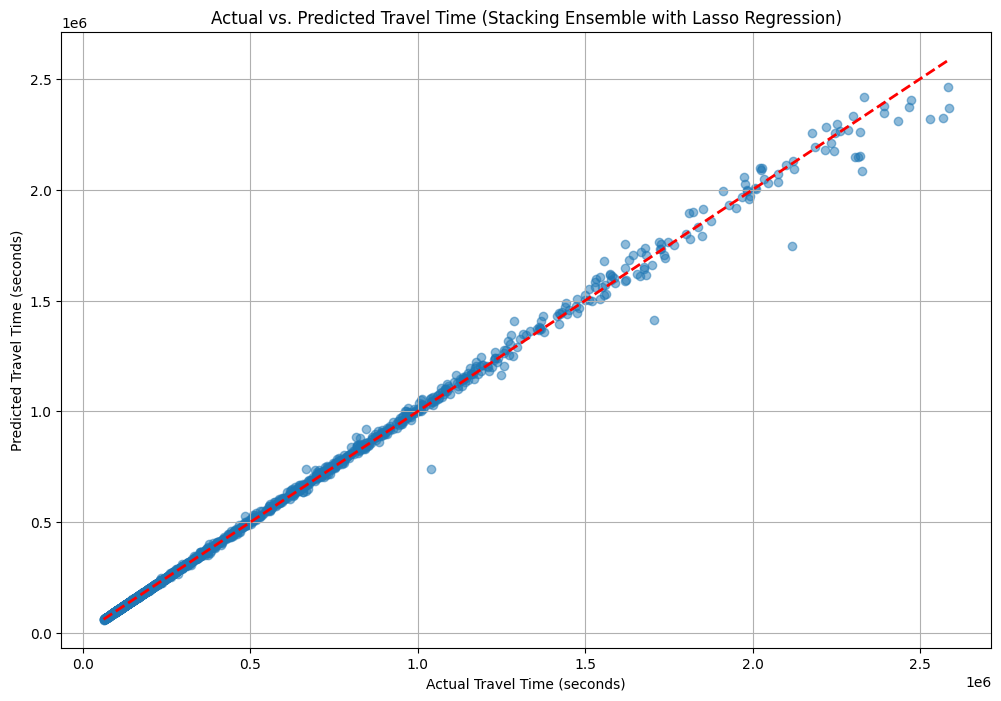

In [24]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, final_predictions, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.title('Actual vs. Predicted Travel Time (Stacking Ensemble with Lasso Regression)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.show()

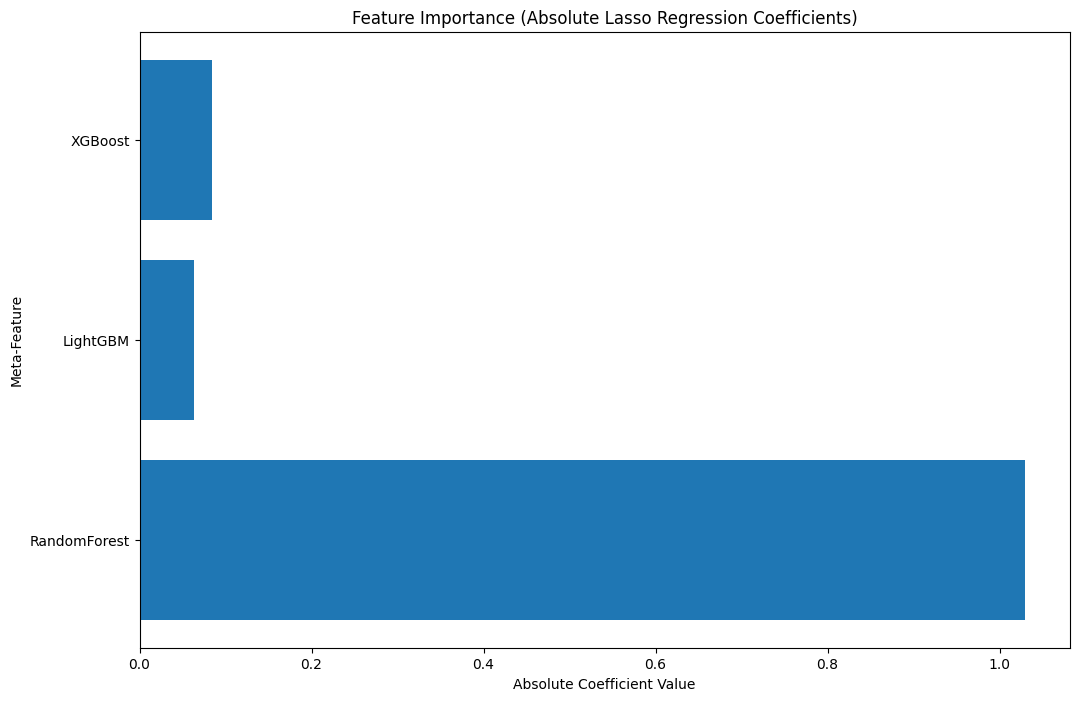

In [29]:
# Feature Importance (Absolute Lasso Coefficients)
feature_names = ['RandomForest', 'LightGBM', 'XGBoost']
lasso_coefficients = np.abs(best_lasso_model.coef_)  # Take absolute values of coefficients

# Plot Feature Importance
plt.figure(figsize=(12, 8))
plt.barh(feature_names, lasso_coefficients)
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Meta-Feature')
plt.title('Feature Importance (Absolute Lasso Regression Coefficients)')
plt.show()

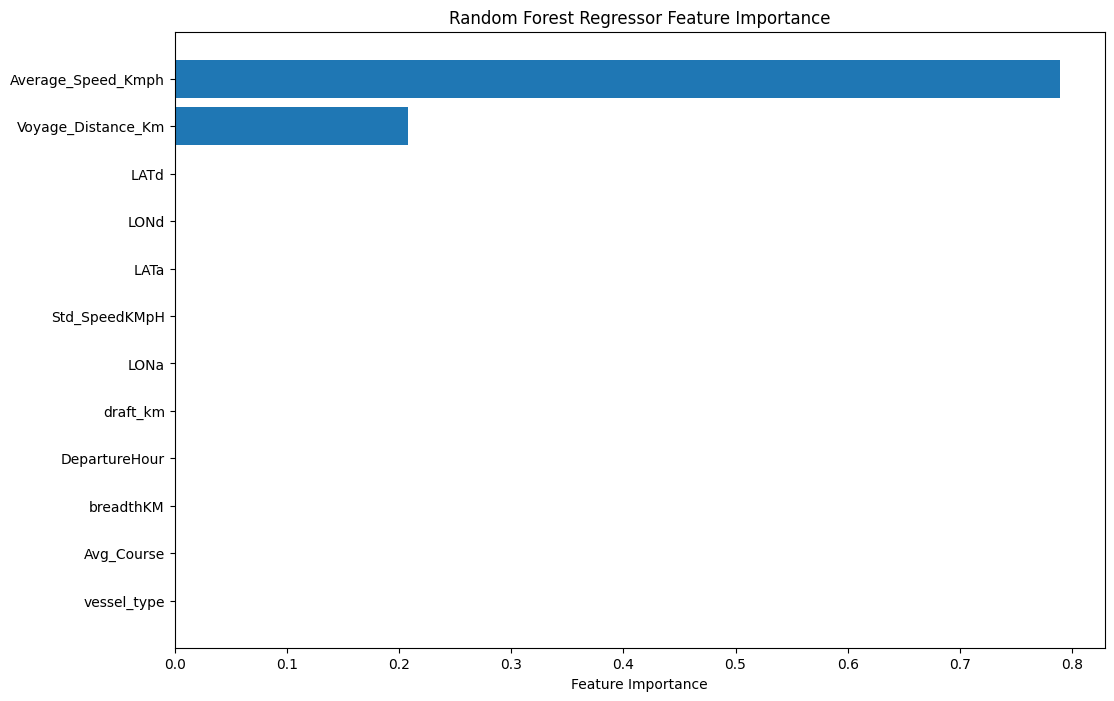

In [25]:
# Feature Importance for Random Forest Model
rf_feature_importance = best_rf_model.feature_importances_
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))

# Aggregate importance for 'vessel_type' (categorical feature)
vessel_type_importance = 0
vessel_type_indices = [i for i, name in enumerate(feature_names) if name.startswith('vessel_type_')]

# Sum the importance of all one-hot encoded columns for 'vessel_type'
for idx in vessel_type_indices:
    vessel_type_importance += rf_feature_importance[idx]

# Remove individual one-hot encoded columns from feature_names and feature_importances
feature_names_aggregated = [name for name in feature_names if not name.startswith('vessel_type_')]
feature_importances_aggregated = [importance for i, importance in enumerate(rf_feature_importance) if i not in vessel_type_indices]

# Add aggregated 'vessel_type' importance
feature_names_aggregated.append('vessel_type')
feature_importances_aggregated.append(vessel_type_importance)

# Sort feature importance in ascending order
sorted_idx = np.argsort(feature_importances_aggregated)

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_idx)), np.array(feature_importances_aggregated)[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(feature_names_aggregated)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Random Forest Regressor Feature Importance')
plt.show()

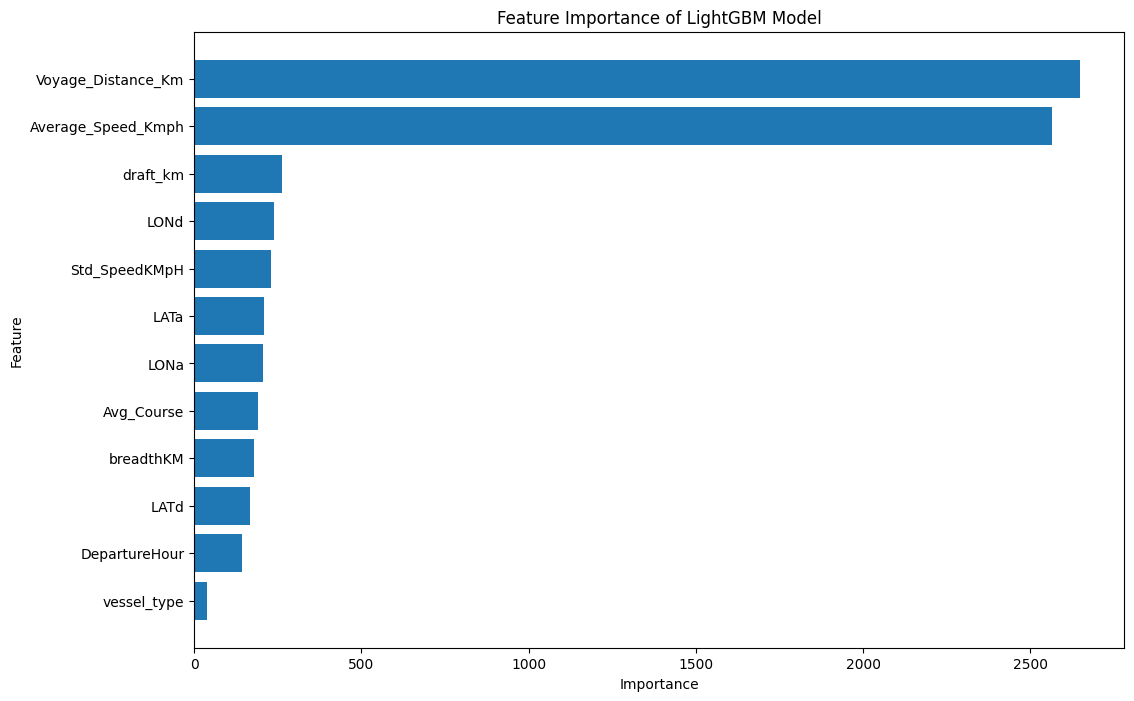

In [26]:
# Function to plot feature importance for LightGBM model
def plot_lgb_feature_importance(model, feature_names):
    importances = model.feature_importances_
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('Feature Importance of LightGBM Model')
    plt.gca().invert_yaxis()
    plt.show()

# Get the correct feature names after preprocessing
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))

# Aggregate importance for 'vessel_type' (categorical feature)
vessel_type_importance = 0
vessel_type_indices = [i for i, name in enumerate(feature_names) if name.startswith('vessel_type_')]

# Sum the importance of all one-hot encoded columns for 'vessel_type'
for idx in vessel_type_indices:
    vessel_type_importance += best_lgb_model.feature_importances_[idx]

# Remove individual one-hot encoded columns from feature_names and feature_importances
feature_names_aggregated = [name for name in feature_names if not name.startswith('vessel_type_')]
feature_importances_aggregated = [importance for i, importance in enumerate(best_lgb_model.feature_importances_) if i not in vessel_type_indices]

# Add aggregated 'vessel_type' importance
feature_names_aggregated.append('vessel_type')
feature_importances_aggregated.append(vessel_type_importance)

# Create a new LightGBM model object with aggregated feature importances
class AggregatedLightGBM:
    def __init__(self, feature_importances, feature_names):
        self.feature_importances_ = feature_importances
        self.feature_name_ = feature_names

# Create an instance of the aggregated model
aggregated_lgb_model = AggregatedLightGBM(feature_importances_aggregated, feature_names_aggregated)

# Plot feature importance
plot_lgb_feature_importance(aggregated_lgb_model, feature_names_aggregated)

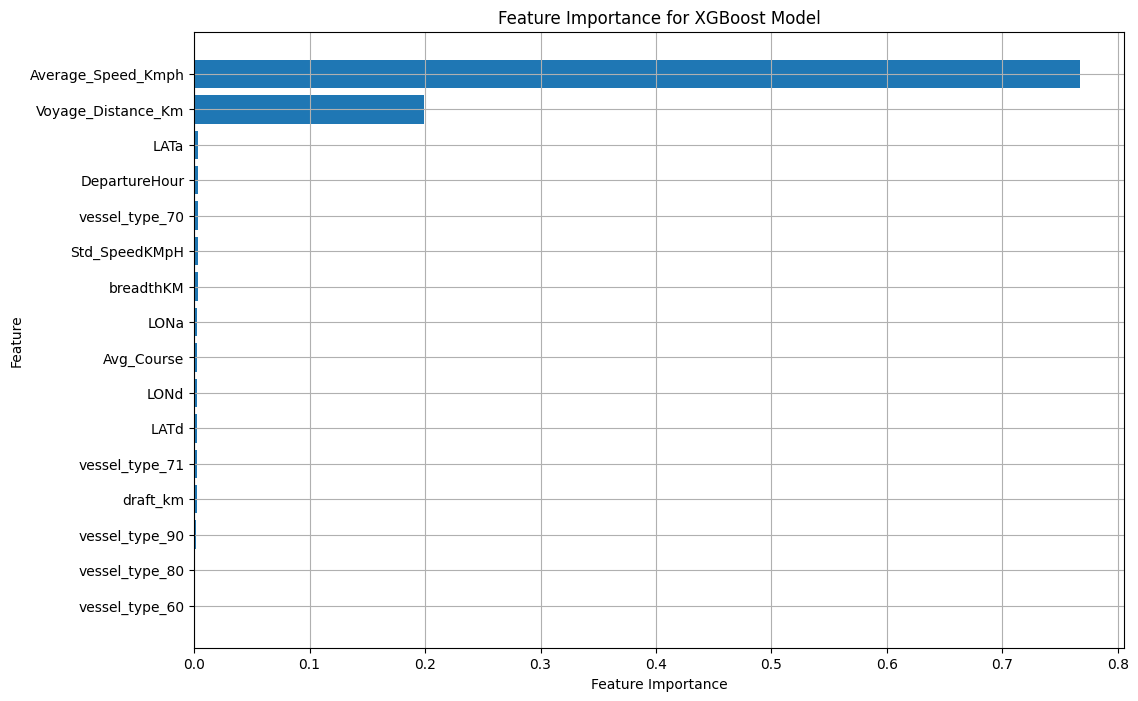

In [31]:
# Get feature importance from the best XGBoost model
xgb_feature_importance = best_xgb_model.model.feature_importances_

# Get feature names after preprocessing
# Note: For categorical features, OneHotEncoder creates multiple columns, so we need to handle that
numeric_feature_names = numeric_features  # Numeric feature names
categorical_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)  # Categorical feature names
all_feature_names = np.concatenate([numeric_feature_names, categorical_feature_names])

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': xgb_feature_importance
})

# Sort features by importance in ascending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)  # Changed to ascending=True

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for XGBoost Model')
plt.grid(True)
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.734e+10, tolerance: 5.470e+09
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.684e+11, tolerance: 1.387e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.003e+11, tolerance: 2.407e

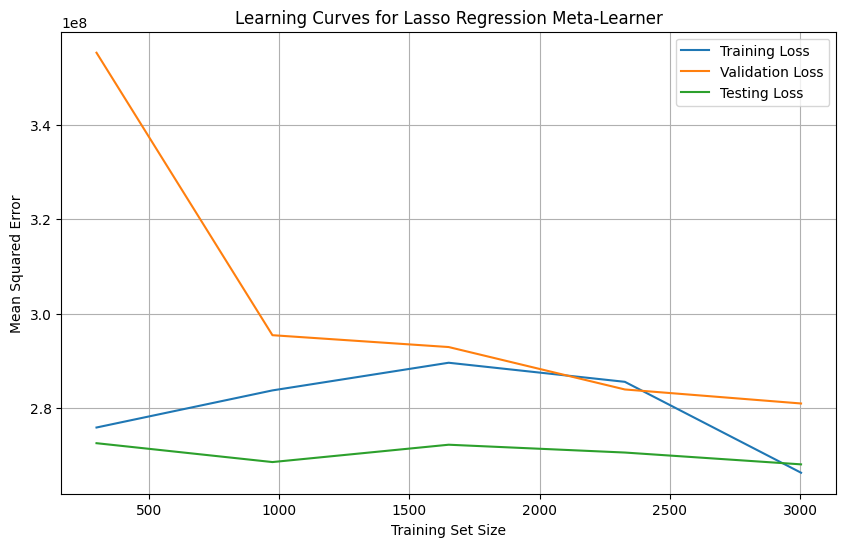

In [28]:
# Generate learning curves for Lasso Regression Meta-Learner
train_sizes, train_scores, val_scores = learning_curve(
    best_lasso_model, meta_features, y_test, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = -train_scores.mean(axis=1)
val_scores_mean = -val_scores.mean(axis=1)

# Calculate test loss at different training set sizes
test_losses = []
for train_size in train_sizes:
    # Train the model on a subset of the training data
    subset_indices = np.random.choice(len(meta_features), int(train_size), replace=False)
    X_subset = meta_features.iloc[subset_indices]
    y_subset = y_test.iloc[subset_indices]

    best_lasso_model.fit(X_subset, y_subset)

    # Evaluate on the test set
    test_pred = best_lasso_model.predict(meta_features)
    test_loss = mean_squared_error(y_test, test_pred)
    test_losses.append(test_loss)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Loss')
plt.plot(train_sizes, val_scores_mean, label='Validation Loss')
plt.plot(train_sizes, test_losses, label='Testing Loss')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curves for Lasso Regression Meta-Learner')
plt.legend()
plt.grid(True)
plt.show()